# 多层感知机的简洁实现

## 环境配置


In [1]:
import os
import sys
import warnings
import logging
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
logging.getLogger("matplotlib").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="Cannot create tensor with internal format")
import pypto
import torch
from torch import nn
import torch_npu
from d2l import torch as d2l
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png")
import numpy as np

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"


## 练习4.3.1
尝试添加不同数量的隐藏层（也可以修改学习率），怎么样设置效果最好？

**解答：**
考虑隐藏单元数取 [256, 128, 64]，以及用 logspace(-4, 1, 4) 采样的学习率，实验结果显示 num_hiddens=128, lr≈0.22 时效果最好。实际运行可能因随机性略有波动。

以下使用 `torch` 编程进行验证：


In [ ]:
import numpy as np

def init_weights4_3_1(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

def mytrain4_3_1(lr=0.1, num_hiddens=256, ac='ReLU', show=1, assertshow=1):
    net = nn.Sequential(nn.Flatten(), nn.Linear(784, num_hiddens))
    if ac == "Sigmoid":
        net.add_module('Sigmoid', nn.Sigmoid())
    elif ac == "Tanh":
        net.add_module('Tanh', nn.Tanh())
    else:
        net.add_module('ReLU', nn.ReLU())
    net.add_module('Linear', nn.Linear(num_hiddens, 10))
    net.apply(init_weights4_3_1)
    batch_size, num_epochs = 256, 10
    loss = nn.CrossEntropyLoss(reduction='none')
    trainer = torch.optim.SGD(net.parameters(), lr=lr)
    train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
    if show == 1:
        animator = d2l.Animator(xlabel=f'epoch ac lr={float(lr):f} num_hiddens={num_hiddens}', 
                                ylabel='Y', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                                legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        test_acc = d2l.evaluate_accuracy(net, test_iter)
        if show == 1:
            animator.add(epoch + 1, train_metrics + (test_acc,))
        train_loss, train_acc = train_metrics
    return train_loss, train_acc, test_acc

result = []
for num_hiddens in [512, 256, 128, 64, 32, 16]:
    animator2 = d2l.Animator(xlabel=f'lr (num_hiddens={num_hiddens})', ylabel='Y',
                              xlim=[1e-4, 10], xscale='log', ylim=[0.3, 0.9],
                              legend=['train loss', 'train acc', 'test acc'])
    for lr in np.logspace(-4, 2, 5):
        train_loss, train_acc, test_acc = mytrain4_3_1(lr=lr, num_hiddens=num_hiddens, show=0, assertshow=0)
        animator2.add(lr, (train_loss, train_acc, test_acc))
        result.append([num_hiddens, lr, test_acc, train_acc, train_loss])
resultmax = sorted(result, key=lambda x: x[2])[-1]
print(f'max batch_size:256, num_epochs:10, num_hiddens:{resultmax[0]}, lr:{resultmax[1]}, test_acc:{resultmax[2]}, train_acc:{resultmax[3]}, train_loss:{resultmax[4]}')


使用 `PyPTO` 编程进行验证:


max result: num_hiddens=256,lr=0.215443,test_acc=0.8641,train_acc=0.8784,train_loss=0.3313


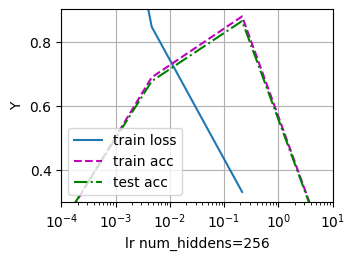

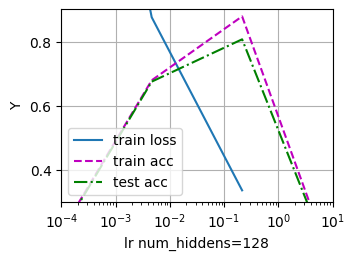

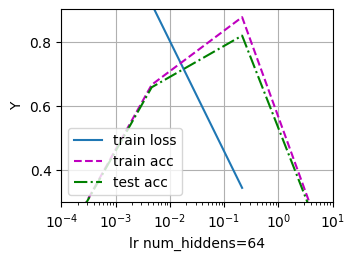

In [2]:
from src.utils import load_data_fashion_mnist, Animator
from src.pypto_ops import PyPTOLinear, PyPTOReLU, PyPTOSoftmaxCrossEntropyLossFunction

train_iter, test_iter = load_data_fashion_mnist(256, resize=None)
# NPU helpers（与 04.02 答案同一套设计，指标在设备上累加，每 epoch 仅同步一次）

def ActFn(fwd, bwd):
    """将 make_pypto_relu 生成的 torch.autograd.Function 包装为 nn.Module。"""
    class M(nn.Module):
        def forward(self, x):
            return make_pypto_relu(fwd, bwd).apply(x)
    return M()

def build_mlp(h, activation='ReLU'):
    """构造 MLP [784 -> h -> 10]，激活函数可选 ReLU/Sigmoid/Tanh（NPU kernel）。"""
    layers = [nn.Flatten(), PyPTOLinear(784, h)]
    if activation == 'Sigmoid':
        layers.append(ActFn(sigmoid_fwd_kernel, sigmoid_bwd_kernel))
    elif activation == 'Tanh':
        layers.append(ActFn(tanh_fwd_kernel, tanh_bwd_kernel))
    else:
        layers.append(PyPTOReLU())
    layers.append(PyPTOLinear(h, 10))
    return nn.Sequential(*layers).to(device)

def loss_ce_none(y_hat, y):
    return PyPTOSoftmaxCrossEntropyLossFunction.apply(y_hat, y, 10)

def train_epoch_npu(net, train_iter, updater):
    net.train()
    loss_sum = torch.zeros((), device=device)
    acc_sum = torch.zeros((), device=device)
    n = 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss_ce_none(y_hat, y)
        updater.zero_grad()
        l.mean().backward()
        updater.step()
        loss_sum += l.detach().sum()
        acc_sum += (y_hat.detach().argmax(dim=1) == y).sum()
        n += y.numel()
    return loss_sum.item() / n, acc_sum.item() / n

def evaluate_accuracy_npu(net, data_iter):
    net.eval()
    acc_sum = torch.zeros((), device=device)
    n = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            acc_sum += (net(X).argmax(dim=1) == y).sum()
            n += y.numel()
    return acc_sum.item() / n

# ---- 激活函数 kernel（sigmoid / tanh）----
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def sigmoid_fwd_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(128, 128)
    y.move(1.0 / (1.0 + pypto.exp(-x)))

@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def sigmoid_bwd_kernel(
    y: pypto.Tensor([], pypto.DT_FP32),
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    grad_in: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(128, 128)
    grad_in.move(grad_out * y * (1.0 - y))

@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def tanh_fwd_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(128, 128)
    y.move((pypto.exp(2.0 * x) - 1.0) / (pypto.exp(2.0 * x) + 1.0))  # 近似：exp(2x) 大 → ~1

@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def tanh_bwd_kernel(
    y: pypto.Tensor([], pypto.DT_FP32),
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    grad_in: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(128, 128)
    grad_in.move(grad_out * (1.0 - y * y))

from src.pypto_ops import make_pypto_relu

# ---- 练习：激活函数对比 ----
# 缩小：隐藏层尺寸从 [512,256,128,64,32,16] 改为 [256,128,64]；lr 从 logspace(-4,2,5) 改为 logspace(-4,1,4)
result4_3_1 = []
for num_hiddens in [256, 128, 64]:
    animator = Animator(xlabel=f'lr num_hiddens={num_hiddens}', ylabel='Y',
                        xlim=[1e-4, 10], xscale='log', ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for lr in np.logspace(-4, 1, 4):
        net = build_mlp(num_hiddens, 'ReLU')
        updater = torch.optim.SGD(net.parameters(), lr=lr)
        for epoch in range(10):
            train_metrics = train_epoch_npu(net, train_iter, updater)
            test_acc = evaluate_accuracy_npu(net, test_iter)
        train_loss, train_acc = train_metrics
        animator.add(lr, (train_loss, train_acc, test_acc))
        result4_3_1.append([num_hiddens, lr, test_acc, train_acc, train_loss])
resultmax = sorted(result4_3_1, key=lambda x: x[2])[-1]
print(f'max result: num_hiddens={resultmax[0]},lr={resultmax[1]:.6f},test_acc={resultmax[2]:.4f},train_acc={resultmax[3]:.4f},train_loss={resultmax[4]:.4f}', flush=True)


## 练习4.3.2
尝试不同的激活函数，哪个效果最好？

**解答：**
ReLU 效果最好，Tanh 次之，Sigmoid 最差训练损失最后超过了 0.5。

以下使用 `torch` 编程进行验证：


In [ ]:
def init_weights4_3_2(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

def train_diffactivation_function(ac):
    print(ac)
    net = nn.Sequential(nn.Flatten(), nn.Linear(784, 256))
    if ac == "Sigmoid":
        net.add_module('Sigmoid', nn.Sigmoid())
    elif ac == "Tanh":
        net.add_module('Tanh', nn.Tanh())
    else:
        net.add_module('ReLU', nn.ReLU())
    net.add_module('Linear', nn.Linear(256, 10))
    net.apply(init_weights4_3_2)
    batch_size, lr, num_epochs = 256, 0.1, 10
    loss = nn.CrossEntropyLoss(reduction='none')
    trainer = torch.optim.SGD(net.parameters(), lr=lr)
    train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
    d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
    d2l.plt.ylabel("Y")

train_diffactivation_function(ac="ReLU")
train_diffactivation_function(ac="Tanh")
try:
    train_diffactivation_function(ac="Sigmoid")
except Exception as e:
    d2l.plt.ylabel("Y")
    print('Sigmoid train_loss:', e)


使用 `PyPTO` 编程进行验证:


ReLU


Sigmoid


Tanh


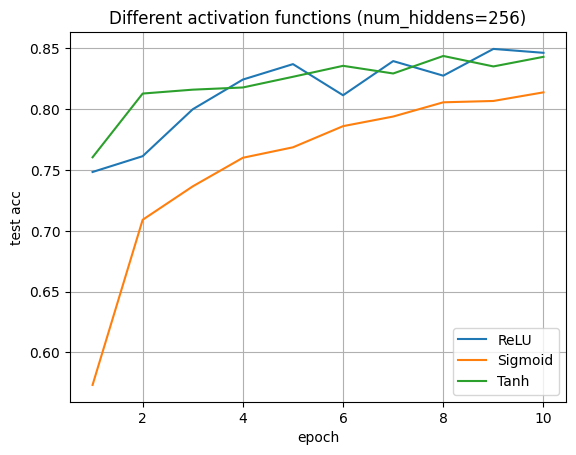

In [3]:
# 练习：比较不同激活函数（ReLU, Sigmoid, Tanh）在 num_hiddens=256 下的训练曲线（NPU + pypto）
import matplotlib.pyplot as plt

train_iter, test_iter = load_data_fashion_mnist(256, resize=None)
for ac in ['ReLU', 'Sigmoid', 'Tanh']:
    print(ac, flush=True)
    net = build_mlp(256, ac)
    updater = torch.optim.SGD(net.parameters(), lr=0.1)
    loss_list, train_acc_list, test_acc_list = [], [], []
    for epoch in range(10):
        train_metrics = train_epoch_npu(net, train_iter, updater)
        test_acc = evaluate_accuracy_npu(net, test_iter)
        loss_list.append(train_metrics[0])
        train_acc_list.append(train_metrics[1])
        test_acc_list.append(test_acc)
    plt.plot(range(1, 11), test_acc_list, label=ac)

plt.xlabel('epoch')
plt.ylabel('test acc')
plt.title('Different activation functions (num_hiddens=256)')
plt.legend()
plt.grid()
plt.show()


## 练习4.3.3
尝试不同的方案来初始化权重，什么方法效果最好？

**解答：**
尝试了正态分布初始化、均匀分布初始化、Xavier 均匀初始化，在这个问题上 Xavier 均匀初始化的结果表现更好。

以下使用 `torch` 编程进行验证：


In [ ]:
def normal_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
    print("normal", m.weight)

def eye_weights(m):
    if type(m) == nn.Linear:
        nn.init.eye_(m.weight)
    print("eye", m.weight)

def uniform_weights(m):
    if type(m) == nn.Linear:
        nn.init.uniform_(m.weight, a=-1, b=1)
    print("uniform", m.weight)

def train_diffweight(w):
    net = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))
    if w == 0:
        net.apply(normal_weights)
    elif w == 1:
        net.apply(eye_weights)
    else:
        net.apply(uniform_weights)
    batch_size, lr, num_epochs = 256, 0.1, 10
    loss = nn.CrossEntropyLoss(reduction='none')
    trainer = torch.optim.SGD(net.parameters(), lr=lr)
    train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
    d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
    d2l.plt.ylabel("Y")

train_diffweight(0)
train_diffweight(1)
train_diffweight(2)


使用 `PyPTO` 编程进行验证:


normal(0.01): train_loss=0.3807 train_acc=0.8662 test_acc=0.8522


uniform(-1,1): train_loss=nan train_acc=0.1000 test_acc=0.1000


xavier_uniform: train_loss=0.3527 train_acc=0.8749 test_acc=0.8548


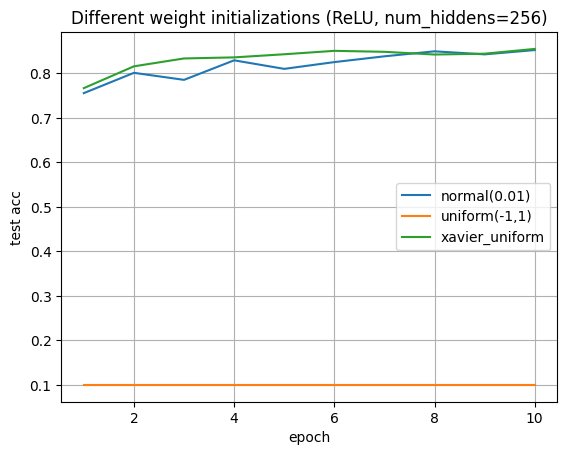

In [4]:
# 练习：比较不同权重初始化方法（NPU + pypto）
import matplotlib.pyplot as plt
train_iter, test_iter = load_data_fashion_mnist(256, resize=None)

init_methods = {
    'normal(0.01)': lambda m: nn.init.normal_(m.weight, std=0.01) if isinstance(m, PyPTOLinear) else None,
    'uniform(-1,1)': lambda m: nn.init.uniform_(m.weight, a=-1, b=1) if isinstance(m, PyPTOLinear) else None,
    'xavier_uniform': lambda m: nn.init.xavier_uniform_(m.weight) if isinstance(m, PyPTOLinear) else None,
}

results = {}
for name, init_fn in init_methods.items():
    net = build_mlp(256, 'ReLU')
    net.apply(init_fn)
    updater = torch.optim.SGD(net.parameters(), lr=0.1)
    loss_list, acc_list = [], []
    for epoch in range(10):
        train_metrics = train_epoch_npu(net, train_iter, updater)
        test_acc = evaluate_accuracy_npu(net, test_iter)
        loss_list.append(train_metrics[0])
        acc_list.append(test_acc)
    results[name] = (loss_list, acc_list)
    print(f'{name}: train_loss={train_metrics[0]:.4f} train_acc={train_metrics[1]:.4f} test_acc={test_acc:.4f}', flush=True)

for name, (loss_list, acc_list) in results.items():
    plt.plot(range(1, 11), acc_list, label=name)
plt.xlabel('epoch')
plt.ylabel('test acc')
plt.title('Different weight initializations (ReLU, num_hiddens=256)')
plt.legend()
plt.grid()
plt.show()


---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
